# 🧪 Stable Diffusion Taller - Generación de Imágenes con Diffusers

## 📦 Instalación (solo necesaria en Colab)

In [1]:
!pip install diffusers transformers accelerate --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 77.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 66.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 50.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 87.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu1

## ⚙️ Verificar acceso a GPU

In [2]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


## 📁 Generar folder de resultados

In [3]:
import os

# Crear carpeta de resultados si no existe
os.makedirs("output_results", exist_ok=True)

## 🚀 Cargar modelo preentrenado Stable Diffusion v1.5

In [4]:
from diffusers import StableDiffusionPipeline
import torch

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
).to("cuda")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

config.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/806 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

## 🖼️ Generar una imagen básica desde un prompt

  0%|          | 0/50 [00:00<?, ?it/s]

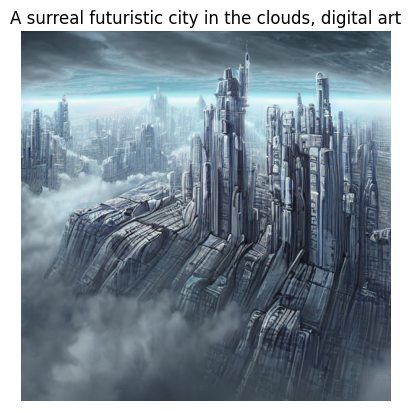

In [5]:
from matplotlib import pyplot as plt
import os

prompt = "A surreal futuristic city in the clouds, digital art"
image = pipe(prompt, num_inference_steps=50, guidance_scale=7.5).images[0]

# Guardar en la carpeta de resultados
image.save("output_results/output_city.png")

# Mostrar
plt.imshow(image)
plt.axis("off")
plt.title(prompt)
plt.show()

## 🔧 Comparación de parámetros: steps y guidance_scale

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/60 [00:00<?, ?it/s]

  0%|          | 0/60 [00:00<?, ?it/s]

  0%|          | 0/60 [00:00<?, ?it/s]

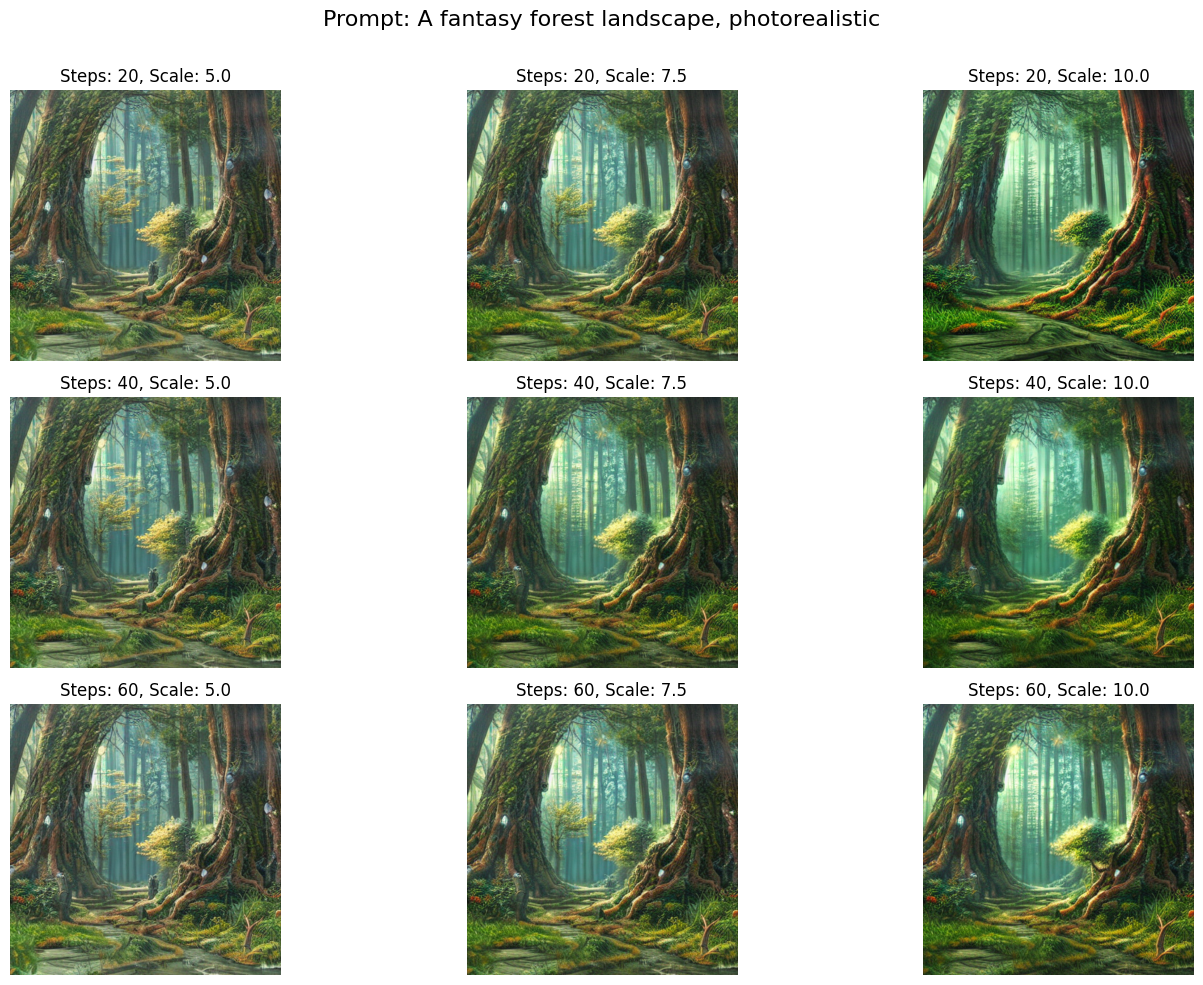

In [6]:
prompt = "A fantasy forest landscape, photorealistic"
guidance_scales = [5.0, 7.5, 10.0]
steps = [20, 40, 60]
seed = 1234

fig, axs = plt.subplots(len(steps), len(guidance_scales), figsize=(15, 10))
fig.suptitle(f"Prompt: {prompt}", fontsize=16)

for i, step in enumerate(steps):
    for j, scale in enumerate(guidance_scales):
        g = torch.Generator("cuda").manual_seed(seed)
        image = pipe(
            prompt,
            height=512,
            width=512,
            num_inference_steps=step,
            guidance_scale=scale,
            generator=g
        ).images[0]

        axs[i][j].imshow(image)
        axs[i][j].axis("off")
        axs[i][j].set_title(f"Steps: {step}, Scale: {scale}")
        image.save(f"output_results/forest_step{step}_scale{scale}.png")

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

## 🎨 Variación de estilos para un mismo prompt

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

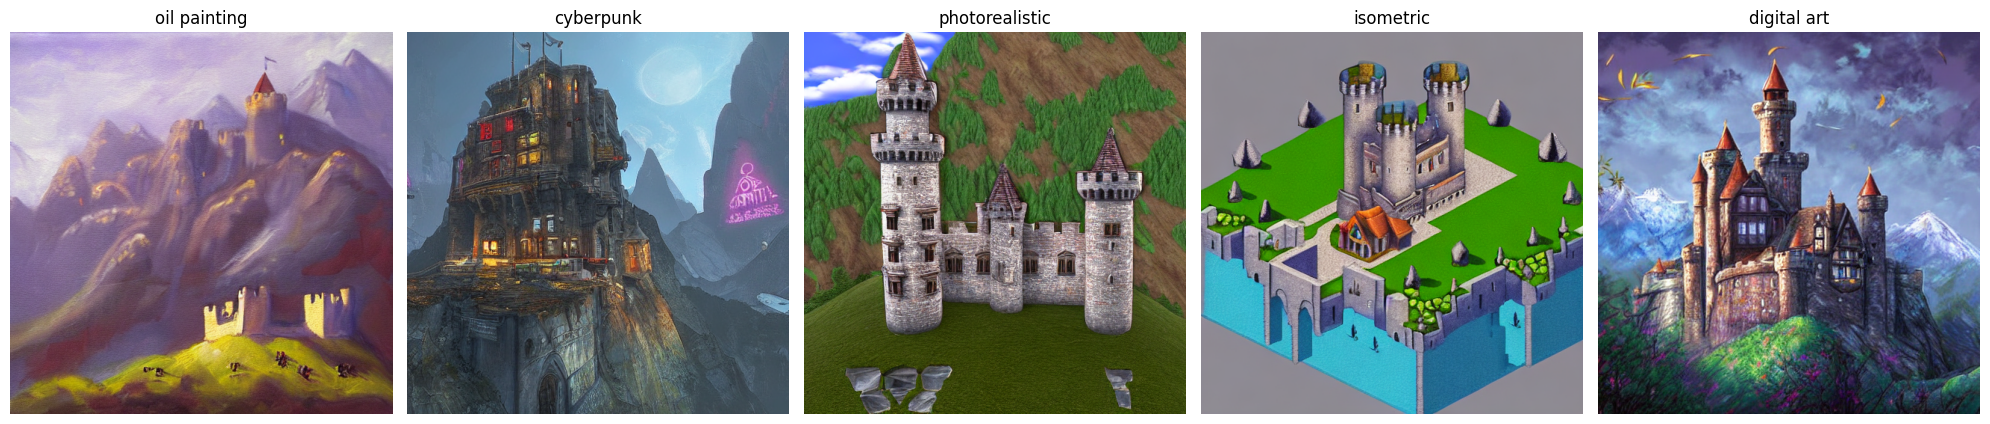

In [7]:
styles = ["oil painting", "cyberpunk", "photorealistic", "isometric", "digital art"]
base_prompt = "A castle in the mountains"

fig, axs = plt.subplots(1, len(styles), figsize=(20, 5))

for i, style in enumerate(styles):
    full_prompt = f"{base_prompt}, {style}"
    image = pipe(full_prompt, num_inference_steps=40, guidance_scale=7.5).images[0]
    axs[i].imshow(image)
    axs[i].axis("off")
    axs[i].set_title(style)
    image.save(f"output_results/castle_{style.replace(' ', '_')}.png")

plt.tight_layout()
plt.show()

## 🚫 Prompt negativo

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

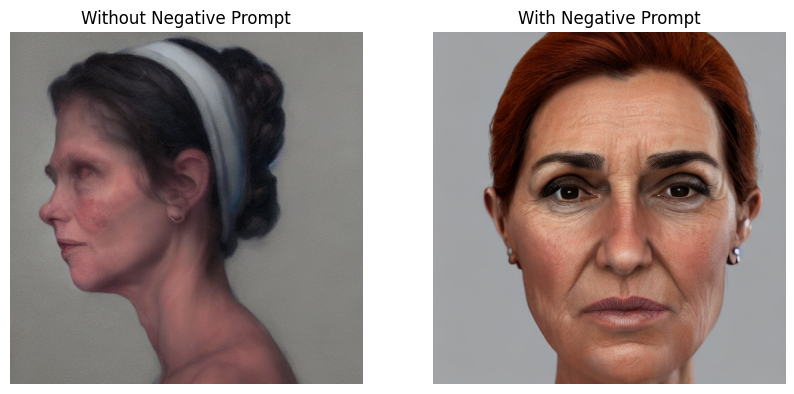

In [8]:
prompt = "A portrait of a woman, realistic, 8k"
negative_prompt = "blurry, distorted, low quality"

image_clean = pipe(prompt, num_inference_steps=40, guidance_scale=8.0).images[0]
image_filtered = pipe(
    prompt,
    negative_prompt=negative_prompt,
    num_inference_steps=40,
    guidance_scale=8.0
).images[0]

image_clean.save("output_results/portrait_clean.png")
image_filtered.save("output_results/portrait_filtered.png")

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(image_clean)
axs[0].axis("off")
axs[0].set_title("Without Negative Prompt")

axs[1].imshow(image_filtered)
axs[1].axis("off")
axs[1].set_title("With Negative Prompt")

plt.show()

## 🖼️ Generación por lotes (batch generation) con seeds diferentes

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

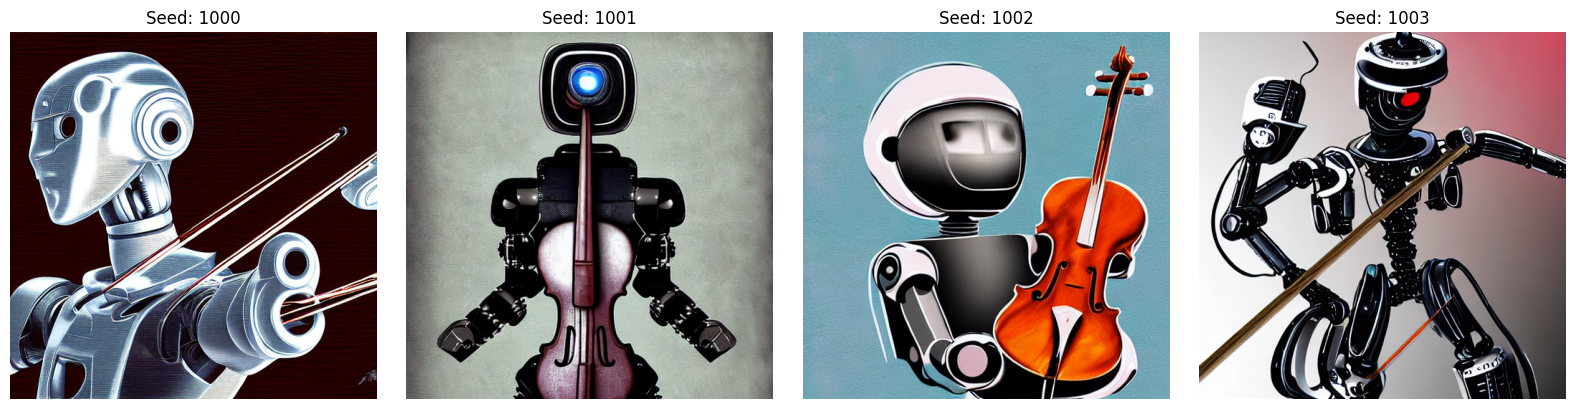

In [9]:
prompt = "A futuristic robot playing the violin, digital art"
num_images = 4

import os
os.makedirs("output_results", exist_ok=True)

fig, axs = plt.subplots(1, num_images, figsize=(16, 4))

for i in range(num_images):
    generator = torch.Generator("cuda").manual_seed(1000 + i)
    image = pipe(prompt, num_inference_steps=30, guidance_scale=7.5, generator=generator).images[0]
    image.save(f"output_results/robot_{i}.png")
    axs[i].imshow(image)
    axs[i].axis("off")
    axs[i].set_title(f"Seed: {1000 + i}")

plt.tight_layout()
plt.show()